# LLM Performance Analysis for O-RAN Intent Processing

This notebook analyzes LLM performance benchmarks across multiple models processing O-RAN network slice intents.

**Models Analyzed:**
- Claude Opus 4.5 (Anthropic)
- Gemini 3 Flash/Pro Preview (Google)
- GPT-5 / GPT-5 Nano (OpenAI)

**Metrics:**
- Token usage (input, output, reasoning)
- Response latency (GPT-5 only)
- Policy creation success rate
- Slice type categorization (eMBB, URLLC, mMTC)

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from datetime import datetime

# Enable inline plotting
%matplotlib inline

# Set consistent plot style (matching other analysis notebooks)
sns.set_theme(style='whitegrid', font_scale=1.7)

print("Libraries loaded ✓")

Libraries loaded ✓


## Configuration

Define data paths, model identifiers, color schemes, slice classification keywords, and API pricing for cost estimation.

In [2]:
# Data paths
RESULTS_DIR = Path("results")

# Model files to analyze
MODEL_FILES = {
    "Claude Opus 4.5": "anthropic-opus-4-5.csv",
    "Claude Sonnet 4.5": "anthropic-sonnet-4-5.csv",
    "Gemini 3 Flash": "gemini-3-flash-preview.csv",
    "Gemini 3 Pro": "gemini-3-pro-preview.csv",
    "GPT-5 Nano": "gpt-5-nano.csv",
    "GPT-5": "gpt-5.csv",
}

# Color scheme based on architecture layers (matching namespace_resources.ipynb)
# Purple for SMO/LLM, Blue for processing, Green for success, Orange for metrics
MODEL_COLORS = {
    "Claude Opus 4.5": "#B39DDB",   # Purple (Anthropic)
    "Claude Sonnet 4.5": "#CE93D8", # Light Purple (Anthropic)
    "Gemini 3 Flash": "#90CAF9",    # Light Blue (Google)
    "Gemini 3 Pro": "#64B5F6",      # Blue (Google)
    "GPT-5 Nano": "#A5D6A7",        # Light Green (OpenAI)
    "GPT-5": "#81C784",             # Green (OpenAI)
}

# Slice type classification keywords
SLICE_KEYWORDS = {
    "URLLC": ["latency", "delay", "ms", "real-time", "autonomous", "robot", "surgery", 
              "control", "industrial", "automation", "toll", "emergency"],
    "mMTC": ["sensor", "iot", "devices", "meter", "monitoring", "agriculture", 
             "parking", "smart city", "environmental"],
    "eMBB": ["video", "stream", "download", "upload", "mbps", "throughput", 
             "bandwidth", "media", "ar", "vr", "gaming", "broadcast"]
}

# Pricing per 1M tokens (USD) - January 2026
# Source: Official pricing pages for each provider
MODEL_PRICING = {
    "Claude Opus 4.5": {"input": 15.00, "output": 75.00},      # Anthropic Opus 4.5
    "Claude Sonnet 4.5": {"input": 3.00, "output": 15.00},     # Anthropic Sonnet 4.5
    "Gemini 3 Flash": {"input": 0.075, "output": 0.30},        # Google Gemini 3 Flash
    "Gemini 3 Pro": {"input": 1.25, "output": 5.00},           # Google Gemini 3 Pro
    "GPT-5 Nano": {"input": 0.15, "output": 0.60},             # OpenAI GPT-5 Nano
    "GPT-5": {"input": 2.50, "output": 10.00},                 # OpenAI GPT-5
}

print("Configuration loaded ✓")
print(f"\nModels to analyze: {list(MODEL_FILES.keys())}")

Configuration loaded ✓

Models to analyze: ['Claude Opus 4.5', 'Claude Sonnet 4.5', 'Gemini 3 Flash', 'Gemini 3 Pro', 'GPT-5 Nano', 'GPT-5']


## Data Loading and Normalization

Load CSV files and normalize column names across different providers.

In [3]:
def classify_slice_type(intent: str) -> str:
    """Classify intent into slice type based on keywords."""
    intent_lower = intent.lower()
    
    # Count keyword matches for each type
    scores = {}
    for slice_type, keywords in SLICE_KEYWORDS.items():
        scores[slice_type] = sum(1 for kw in keywords if kw in intent_lower)
    
    # Return type with highest score, default to eMBB
    if max(scores.values()) == 0:
        return "eMBB"  # Default
    return max(scores, key=scores.get)


def load_and_normalize(model_name: str, filename: str) -> pd.DataFrame:
    """Load CSV and normalize column names."""
    filepath = RESULTS_DIR / filename
    
    if not filepath.exists():
        print(f"  ✗ {model_name}: File not found")
        return pd.DataFrame()
    
    df = pd.read_csv(filepath)
    
    if df.empty or len(df) == 0:
        print(f"  ✗ {model_name}: Empty file")
        return pd.DataFrame()
    
    # Add model name
    df["model_name"] = model_name
    
    # Normalize column names based on provider
    if "anthropic" in filename:
        df = df.rename(columns={
            "usage_input_tokens": "input_tokens",
            "usage_output_tokens": "output_tokens",
            "tool_use_names": "function_call",
            "column": "response_kind",  # Sonnet CSV uses 'column' instead of 'response_kind'
        })
        df["reasoning_tokens"] = 0  # Anthropic doesn't expose reasoning tokens
        df["provider"] = "Anthropic"
        
    elif "gemini" in filename:
        df = df.rename(columns={
            "prompt_token_count": "input_tokens",
            "candidates_token_count": "output_tokens",
            "thoughts_token_count": "reasoning_tokens",
            "function_call_name": "function_call",
        })
        df["provider"] = "Google"
        # Note: Gemini CSVs should have policy_status column like other providers
        
    elif "gpt" in filename:
        df = df.rename(columns={
            "usage_input_tokens": "input_tokens",
            "usage_output_tokens": "output_tokens",
            "usage_output_tokens_reasoning": "reasoning_tokens",
            "function_call_name": "function_call",
        })
        df["provider"] = "OpenAI"
        
        # Calculate latency from timestamps
        if "created_at" in df.columns and "completed_at" in df.columns:
            df["created_at"] = pd.to_datetime(df["created_at"])
            df["completed_at"] = pd.to_datetime(df["completed_at"])
            df["latency_seconds"] = (df["completed_at"] - df["created_at"]).dt.total_seconds()
    
    # Classify slice type
    df["slice_type"] = df["intent"].apply(classify_slice_type)
    
    # Calculate total tokens (per row)
    df["total_tokens"] = df["input_tokens"] + df["output_tokens"] + df.get("reasoning_tokens", 0)
    
    # Calculate cost (USD) per row
    pricing = MODEL_PRICING.get(model_name, {"input": 0, "output": 0})
    df["cost_input"] = df["input_tokens"] * pricing["input"] / 1_000_000
    df["cost_output"] = df["output_tokens"] * pricing["output"] / 1_000_000
    df["cost_total"] = df["cost_input"] + df["cost_output"]
    
    print(f"  ✓ {model_name}: {len(df)} rows loaded")
    return df


def aggregate_per_intent(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate data per intent (combining intent_processing + type_definition rows).
    Each intent spans 2 rows in the CSV - this sums tokens/costs for accurate per-intent metrics.
    """
    # Group by model and intent, summing tokens and costs
    intent_agg = df.groupby(["model_name", "intent", "provider", "slice_type"]).agg({
        "input_tokens": "sum",
        "output_tokens": "sum",
        "reasoning_tokens": "sum",
        "total_tokens": "sum",
        "cost_input": "sum",
        "cost_output": "sum",
        "cost_total": "sum",
        "response_kind": lambda x: set(x),  # Collect response kinds
        "policy_status": lambda x: x.dropna().tolist(),  # Collect non-null statuses
    }).reset_index()
    
    # Determine if intent is complete (has both response_kinds)
    intent_agg["has_intent_processing"] = intent_agg["response_kind"].apply(
        lambda x: "intent_processing" in x
    )
    intent_agg["has_type_definition"] = intent_agg["response_kind"].apply(
        lambda x: "type_definition" in x
    )
    intent_agg["is_complete"] = intent_agg["has_intent_processing"] & intent_agg["has_type_definition"]
    
    # Determine success: complete intent with all policy_status containing "success"
    def check_success(row):
        if not row["is_complete"]:
            return False  # Incomplete intents are failures
        statuses = row["policy_status"]
        if not statuses:
            return False  # No status recorded
        return all("success" in str(s).lower() for s in statuses)
    
    intent_agg["success"] = intent_agg.apply(check_success, axis=1)
    
    # Add latency if available (from intent_processing row only)
    if "latency_seconds" in df.columns:
        latency_df = df[df["response_kind"] == "intent_processing"][["model_name", "intent", "latency_seconds"]]
        intent_agg = intent_agg.merge(latency_df, on=["model_name", "intent"], how="left")
    
    return intent_agg


# Load all data
print("Loading model data...")
dataframes = {}
for model_name, filename in MODEL_FILES.items():
    df = load_and_normalize(model_name, filename)
    if not df.empty:
        dataframes[model_name] = df

# Combine all data (row-level)
all_data = pd.concat(dataframes.values(), ignore_index=True)
print(f"\nTotal records (rows): {len(all_data)}")

# Aggregate per intent (combining both rows per intent)
intent_data = aggregate_per_intent(all_data)
print(f"Total intents: {len(intent_data)}")

Loading model data...
  ✓ Claude Opus 4.5: 200 rows loaded
  ✓ Claude Sonnet 4.5: 117 rows loaded
  ✓ Gemini 3 Flash: 143 rows loaded
  ✓ Gemini 3 Pro: 156 rows loaded
  ✓ GPT-5 Nano: 197 rows loaded
  ✓ GPT-5: 200 rows loaded

Total records (rows): 1013
Total intents: 555


In [4]:
# Data summary
print("=" * 80)
print("DATA SUMMARY (Per Intent - aggregated from 2 rows each)")
print("=" * 80)

summary = intent_data.groupby("model_name").agg({
    "intent": "count",
    "input_tokens": "mean",
    "output_tokens": "mean",
    "reasoning_tokens": "mean",
    "is_complete": "sum",
    "success": "sum",
}).rename(columns={"intent": "intents", "is_complete": "complete", "success": "successful"})

print(summary.round(1).to_string())

print("\n" + "-" * 80)
print("Data Quality (intents with both intent_processing + type_definition rows):")
quality = intent_data.groupby("model_name").agg({
    "intent": "count",
    "is_complete": ["sum", "mean"]
})
quality.columns = ["total_intents", "complete_intents", "completeness_rate"]
quality["completeness_rate"] = (quality["completeness_rate"] * 100).round(1)
print(quality.to_string())

print("\n" + "-" * 80)
print("Slice Type Distribution:")
print(intent_data.groupby(["model_name", "slice_type"]).size().unstack(fill_value=0).to_string())

DATA SUMMARY (Per Intent - aggregated from 2 rows each)
                   intents  input_tokens  output_tokens  reasoning_tokens  complete  successful
model_name                                                                                     
Claude Opus 4.5        100       18547.6          200.5               0.0       100         100
Claude Sonnet 4.5      100       15269.8          153.7               0.0        17          17
GPT-5                  100       27305.6          774.7             680.3       100         100
GPT-5 Nano             100       26348.8         1512.4            1420.8        97          97
Gemini 3 Flash          77       15090.3         2417.7            5271.7        66          66
Gemini 3 Pro            78       15225.6         2393.9            4677.7        78          78

--------------------------------------------------------------------------------
Data Quality (intents with both intent_processing + type_definition rows):
                   

## Plot 1: Token Usage Comparison by Model

Grouped bar chart showing mean input/output tokens per intent (summed across both rows: `intent_processing` + `type_definition`).

In [5]:
# Calculate statistics per model (using per-intent aggregated data)
token_stats = intent_data.groupby("model_name").agg({
    "input_tokens": ["mean", "std"],
    "output_tokens": ["mean", "std"],
}).round(1)

# Flatten column names
token_stats.columns = ["_".join(col) for col in token_stats.columns]
token_stats = token_stats.reset_index()

# Order models consistently
model_order = [m for m in MODEL_FILES.keys() if m in token_stats["model_name"].values]
token_stats["model_name"] = pd.Categorical(token_stats["model_name"], categories=model_order, ordered=True)
token_stats = token_stats.sort_values("model_name")

print("Token Statistics (per intent - both rows summed):")
print(token_stats.to_string(index=False))

Token Statistics (per intent - both rows summed):
       model_name  input_tokens_mean  input_tokens_std  output_tokens_mean  output_tokens_std
  Claude Opus 4.5            18547.6            9417.0               200.5              112.6
Claude Sonnet 4.5            15269.8            9679.0               153.7               15.5
   Gemini 3 Flash            15090.3            8308.3              2417.7             2028.0
     Gemini 3 Pro            15225.6            8172.6              2393.9             2786.7
       GPT-5 Nano            26348.8           14797.3              1512.4              380.5
            GPT-5            27305.6           15137.8               774.7              226.1


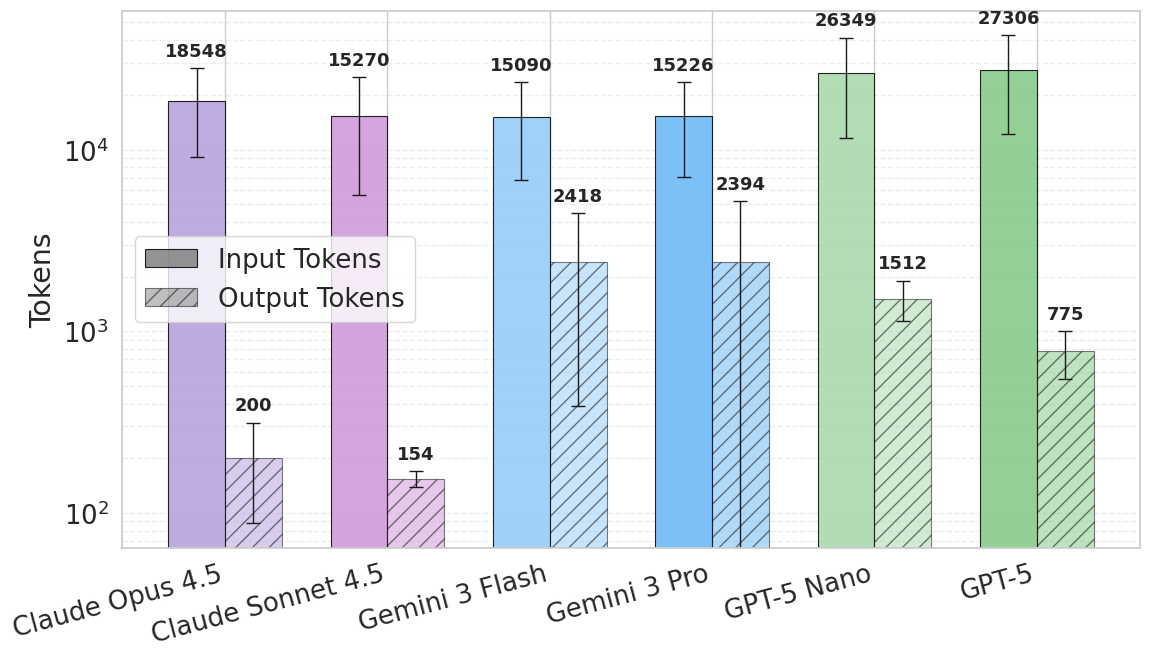


✓ Chart saved to: llm_token_usage_comparison.png


In [6]:
# Create grouped bar chart for token usage
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(token_stats))
width = 0.35

# Get colors for each model
colors = [MODEL_COLORS[m] for m in token_stats["model_name"]]

# Input tokens bars
bars1 = ax.bar(x - width/2, token_stats["input_tokens_mean"], width, 
               yerr=token_stats["input_tokens_std"], 
               label="Input Tokens", color=colors, alpha=0.85,
               edgecolor="black", linewidth=0.8,
               capsize=5, error_kw=dict(lw=1, capsize=5, capthick=1))

# Output tokens bars (darker shade)
bars2 = ax.bar(x + width/2, token_stats["output_tokens_mean"], width,
               yerr=token_stats["output_tokens_std"],
               label="Output Tokens", color=colors, alpha=0.5,
               edgecolor="black", linewidth=0.8, hatch="//",
               capsize=5, error_kw=dict(lw=1, capsize=5, capthick=1))

ax.set_ylabel("Tokens")
ax.set_xticks(x)
ax.set_xticklabels(token_stats["model_name"], rotation=15, ha="right")
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")

# Custom legend with grey colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#808080", edgecolor="black", linewidth=0.8, alpha=0.85, label="Input Tokens"),
    Patch(facecolor="#808080", edgecolor="black", linewidth=0.8, alpha=0.5, hatch="//", label="Output Tokens"),
]
ax.legend(handles=legend_elements, loc="center left")

# Add value labels on input bars (positioned above stddev error bars)
for bar, val, std in zip(bars1, token_stats["input_tokens_mean"], token_stats["input_tokens_std"]):
    ax.annotate(f"{val:.0f}",
                xy=(bar.get_x() + bar.get_width()/2, val + std),
                xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=13, fontweight="bold")

# Add value labels on output bars (positioned above stddev error bars)
for bar, val, std in zip(bars2, token_stats["output_tokens_mean"], token_stats["output_tokens_std"]):
    ax.annotate(f"{val:.0f}",
                xy=(bar.get_x() + bar.get_width()/2, val + std),
                xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("llm_token_usage_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_token_usage_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_token_usage_comparison.png")

## Plot 2: Token Usage by Slice Type

Compare token consumption across different slice categories (eMBB, URLLC, mMTC).

In [7]:
# Calculate tokens by slice type and model (per-intent aggregated)
slice_stats = intent_data.groupby(["model_name", "slice_type"]).agg({
    "input_tokens": "mean",
    "output_tokens": "mean",
    "intent": "count"
}).rename(columns={"intent": "count"}).reset_index()

# Pivot for plotting
slice_pivot = slice_stats.pivot(index="model_name", columns="slice_type", values="input_tokens")
slice_pivot = slice_pivot.reindex(model_order)

print("Input Tokens by Slice Type (mean per intent):")
print(slice_pivot.round(0).to_string())

Input Tokens by Slice Type (mean per intent):
slice_type           URLLC     eMBB     mMTC
model_name                                  
Claude Opus 4.5    19380.0  18575.0  16143.0
Claude Sonnet 4.5  14462.0  14003.0  19028.0
Gemini 3 Flash     14852.0  10460.0  21215.0
Gemini 3 Pro       15344.0  11866.0  19365.0
GPT-5 Nano         26577.0  18863.0  34305.0
GPT-5              27549.0  19593.0  35481.0


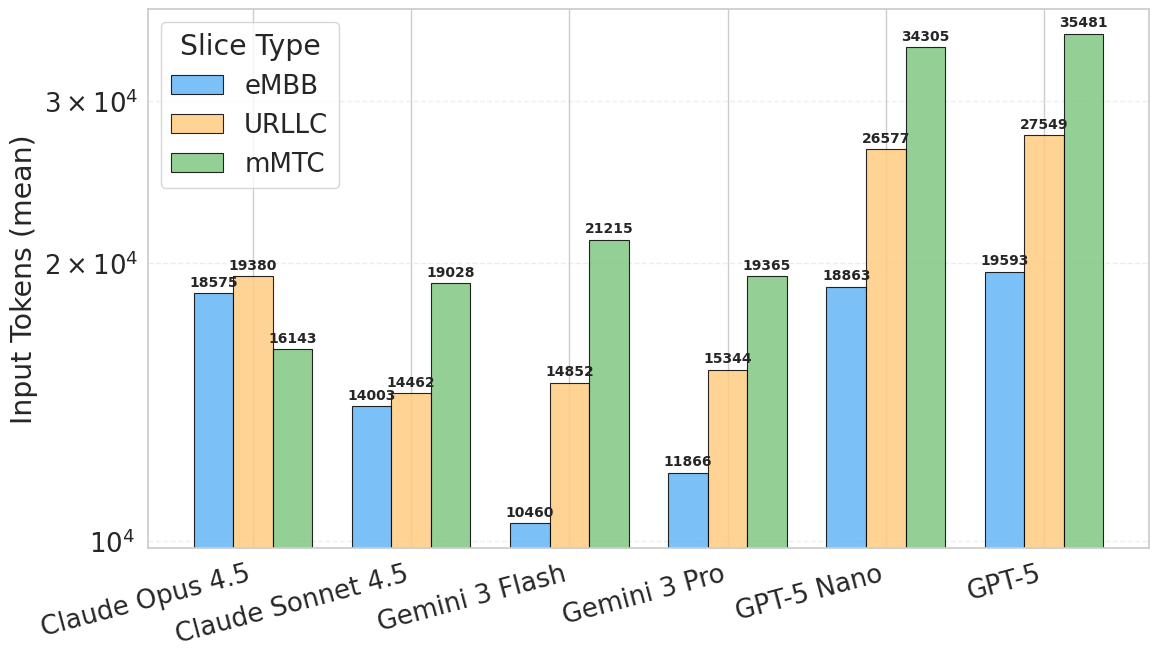


✓ Chart saved to: llm_tokens_by_slice_type.png


In [8]:
# Create grouped bar chart by slice type
fig, ax = plt.subplots(figsize=(12, 7))

slice_types = ["eMBB", "URLLC", "mMTC"]
slice_colors = {"eMBB": "#64B5F6", "URLLC": "#FFCC80", "mMTC": "#81C784"}

x = np.arange(len(slice_pivot))
width = 0.25

for i, slice_type in enumerate(slice_types):
    if slice_type in slice_pivot.columns:
        values = slice_pivot[slice_type].fillna(0).values
        bars = ax.bar(x + i*width, values, width, 
                      label=slice_type, color=slice_colors[slice_type],
                      edgecolor="black", linewidth=0.8, alpha=0.85)
        
        # Add value labels
        for bar, val in zip(bars, values):
            if val > 0:
                ax.annotate(f"{val:.0f}",
                            xy=(bar.get_x() + bar.get_width()/2, val),
                            xytext=(0, 3), textcoords="offset points",
                            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Input Tokens (mean)")
ax.set_xticks(x + width)
ax.set_xticklabels(slice_pivot.index, rotation=15, ha="right")
ax.legend(title="Slice Type")
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")

plt.tight_layout()
plt.savefig("llm_tokens_by_slice_type.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_tokens_by_slice_type.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_tokens_by_slice_type.png")

## Plot 3: Token Breakdown (Input / Output / Reasoning)

Stacked bar chart showing input vs output vs reasoning token proportions for all models.

**Note:** Anthropic models (Claude) show 0 reasoning tokens because the API doesn't expose this metric. Gemini and GPT-5 report reasoning/thinking tokens separately.

In [9]:
# Calculate reasoning token statistics for all models (including Anthropic with 0 reasoning)
reasoning_stats = intent_data.groupby("model_name").agg({
    "input_tokens": "mean",
    "output_tokens": "mean",
    "reasoning_tokens": "mean",
}).round(0)

# Reorder
reasoning_order = [m for m in model_order if m in reasoning_stats.index]
reasoning_stats = reasoning_stats.reindex(reasoning_order)

print("Token Breakdown Statistics (per intent):")
print(reasoning_stats.to_string())

# Calculate percentages
reasoning_stats["total"] = reasoning_stats.sum(axis=1)
for col in ["input_tokens", "output_tokens", "reasoning_tokens"]:
    reasoning_stats[f"{col}_pct"] = (reasoning_stats[col] / reasoning_stats["total"] * 100).round(1)

print("\nPercentage breakdown:")
print(reasoning_stats[["input_tokens_pct", "output_tokens_pct", "reasoning_tokens_pct"]].to_string())

Token Breakdown Statistics (per intent):
                   input_tokens  output_tokens  reasoning_tokens
model_name                                                      
Claude Opus 4.5         18548.0          200.0               0.0
Claude Sonnet 4.5       15270.0          154.0               0.0
Gemini 3 Flash          15090.0         2418.0            5272.0
Gemini 3 Pro            15226.0         2394.0            4678.0
GPT-5 Nano              26349.0         1512.0            1421.0
GPT-5                   27306.0          775.0             680.0

Percentage breakdown:
                   input_tokens_pct  output_tokens_pct  reasoning_tokens_pct
model_name                                                                  
Claude Opus 4.5                98.9                1.1                   0.0
Claude Sonnet 4.5              99.0                1.0                   0.0
Gemini 3 Flash                 66.2               10.6                  23.1
Gemini 3 Pro                   

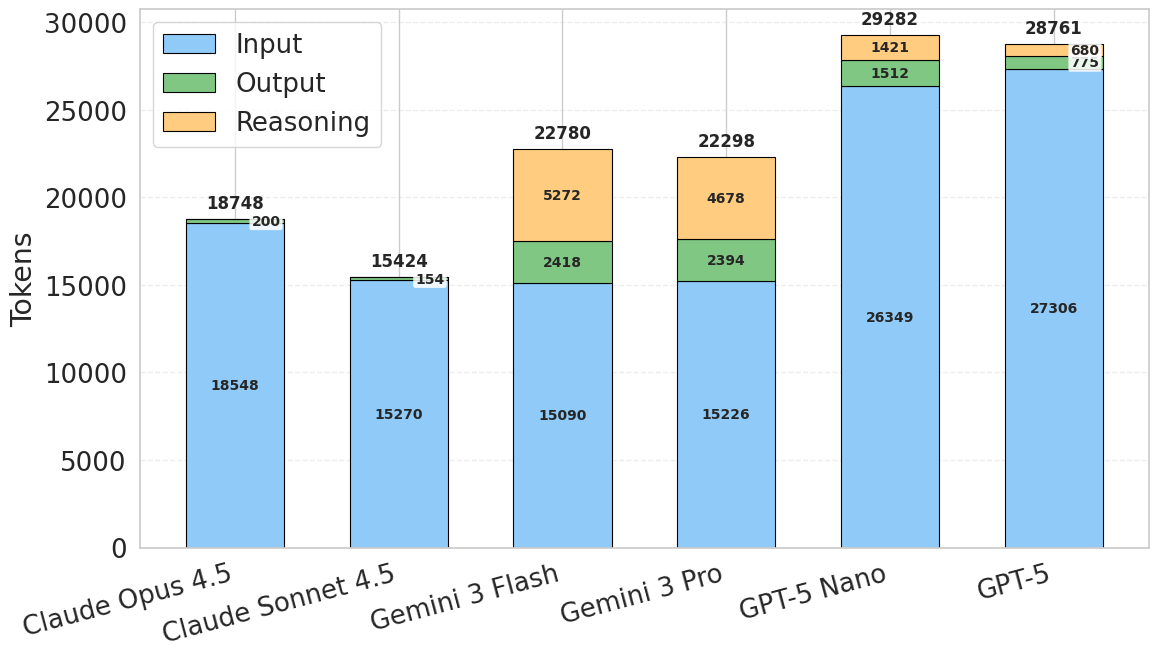


✓ Chart saved to: llm_token_breakdown.png
Note: Anthropic models show 0 reasoning tokens (not exposed in API)


In [24]:
# Create stacked bar chart for token breakdown (all models)
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(reasoning_stats))
width = 0.6

# Stack: Input (bottom), Output (middle), Reasoning (top)
bars1 = ax.bar(x, reasoning_stats["input_tokens"], width, 
               label="Input", color="#90CAF9", edgecolor="black", linewidth=0.8)
bars2 = ax.bar(x, reasoning_stats["output_tokens"], width, 
               bottom=reasoning_stats["input_tokens"],
               label="Output", color="#81C784", edgecolor="black", linewidth=0.8)
bars3 = ax.bar(x, reasoning_stats["reasoning_tokens"], width,
               bottom=reasoning_stats["input_tokens"] + reasoning_stats["output_tokens"],
               label="Reasoning", color="#FFCC80", edgecolor="black", linewidth=0.8)

ax.set_ylabel("Tokens")
ax.set_xticks(x)
ax.set_xticklabels(reasoning_stats.index, rotation=15, ha="right")
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.35)

# Add labels: total on top for all bars, segment values for every positive segment
# For very small segments, shift label to the side to avoid overlapping border lines.
small_segment_threshold = 800
for i, (idx, row) in enumerate(reasoning_stats.iterrows()):
    input_val = row["input_tokens"]
    output_val = row["output_tokens"]
    reasoning_val = row["reasoning_tokens"]
    total = row["total"]

    ax.annotate(f"{total:.0f}",
                xy=(i, total),
                xytext=(0, 5), textcoords="offset points",
                ha="center", va="bottom", fontsize=12, fontweight="bold")

    if input_val > 0:
        ax.annotate(f"{input_val:.0f}",
                    xy=(i, input_val / 2),
                    ha="center", va="center", fontsize=10, fontweight="bold")

    if output_val > 0:
        output_mid = input_val + output_val / 2
        if output_val < small_segment_threshold:
            ax.annotate(f"{output_val:.0f}",
                        xy=(i, output_mid),
                        xytext=(12, 0), textcoords="offset points",
                        ha="left", va="center", fontsize=10, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85))
        else:
            ax.annotate(f"{output_val:.0f}",
                        xy=(i, output_mid),
                        ha="center", va="center", fontsize=10, fontweight="bold")

    if reasoning_val > 0:
        reasoning_mid = input_val + output_val + reasoning_val / 2
        if reasoning_val < small_segment_threshold:
            ax.annotate(f"{reasoning_val:.0f}",
                        xy=(i, reasoning_mid),
                        xytext=(12, 0), textcoords="offset points",
                        ha="left", va="center", fontsize=10, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85))
        else:
            ax.annotate(f"{reasoning_val:.0f}",
                        xy=(i, reasoning_mid),
                        ha="center", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("llm_token_breakdown.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_token_breakdown.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_token_breakdown.png")
print("Note: Anthropic models show 0 reasoning tokens (not exposed in API)")

## Plot 4: Response Latency (GPT-5 Only)

Box plot comparing response latency between GPT-5 and GPT-5 Nano.

**Note:** Only OpenAI GPT-5 models report response latency in the API response. Anthropic and Google APIs do not expose this metric, so those models are excluded from this analysis.

In [11]:
# Filter models with latency data (GPT-5 only)
latency_data = intent_data[intent_data["latency_seconds"].notna()].copy()

if len(latency_data) > 0:
    latency_stats = latency_data.groupby("model_name")["latency_seconds"].agg(["mean", "std", "min", "max", "count"])
    print("Latency Statistics (seconds):")
    print(latency_stats.round(2).to_string())
else:
    print("No latency data available.")

Latency Statistics (seconds):
             mean   std  min   max  count
model_name                               
GPT-5       11.24  4.65  5.0  34.0    100
GPT-5 Nano  10.52  3.35  5.0  20.0    100


/tmp/ipykernel_798439/3119816150.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([latency_data[latency_data["model_name"] == m]["latency_seconds"] for m in latency_order],


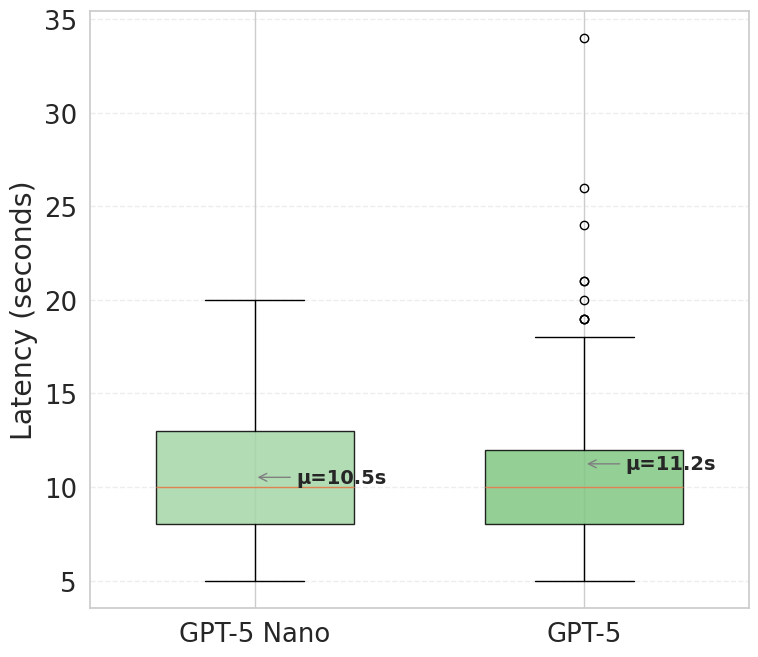


✓ Chart saved to: llm_response_latency.png


In [12]:
# Create box plot for latency
if len(latency_data) > 0:
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Order models
    latency_order = [m for m in ["GPT-5 Nano", "GPT-5"] if m in latency_data["model_name"].unique()]
    colors_lat = [MODEL_COLORS[m] for m in latency_order]
    
    # Create box plot
    bp = ax.boxplot([latency_data[latency_data["model_name"] == m]["latency_seconds"] for m in latency_order],
                    labels=latency_order, patch_artist=True, widths=0.6)
    
    # Color boxes
    for patch, color in zip(bp["boxes"], colors_lat):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor("black")
    
    ax.set_ylabel("Latency (seconds)")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    
    # Add mean values
    for i, model in enumerate(latency_order):
        mean_val = latency_data[latency_data["model_name"] == model]["latency_seconds"].mean()
        ax.annotate(f"μ={mean_val:.1f}s",
                    xy=(i+1, mean_val),
                    xytext=(30, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=14, fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color="gray"))
    
    plt.tight_layout()
    plt.savefig("llm_response_latency.png", dpi=300, bbox_inches="tight")
    plt.savefig("llm_response_latency.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("\n✓ Chart saved to: llm_response_latency.png")
else:
    print("Skipping latency chart - no data available.")

## Plot 5: Policy Success Rate

Horizontal bar chart comparing policy creation success rates by model.

**Success criteria:** An intent is successful when:
1. Both rows exist (`intent_processing` + `type_definition`)
2. All `policy_status` values contain "success"

Intents with missing `type_definition` row count as failures.

In [13]:
# Calculate success rates using pre-computed success column
# Success = complete intent (both rows) + all policy_status containing "success"
success_stats = intent_data.groupby("model_name").agg({
    "success": ["sum", "count"]
})
success_stats.columns = ["successes", "total"]
success_stats["success_rate"] = (success_stats["successes"] / success_stats["total"] * 100).round(1)

# Reorder
success_order = [m for m in model_order if m in success_stats.index]
success_stats = success_stats.reindex(success_order)

print("Policy Success Rates (intent must have both rows + successful status):")
print(success_stats.to_string())

# Show breakdown of failures
print("\n" + "-" * 60)
print("Failure Breakdown:")
failure_analysis = intent_data.groupby("model_name").agg({
    "intent": "count",
    "is_complete": "sum",
    "success": "sum"
})
failure_analysis.columns = ["total", "complete", "successful"]
failure_analysis["incomplete"] = failure_analysis["total"] - failure_analysis["complete"]
failure_analysis["complete_but_failed"] = failure_analysis["complete"] - failure_analysis["successful"]
failure_analysis = failure_analysis.reindex(success_order)
print(failure_analysis[["total", "incomplete", "complete_but_failed", "successful"]].to_string())

Policy Success Rates (intent must have both rows + successful status):
                   successes  total  success_rate
model_name                                       
Claude Opus 4.5          100    100         100.0
Claude Sonnet 4.5         17    100          17.0
Gemini 3 Flash            66     77          85.7
Gemini 3 Pro              78     78         100.0
GPT-5 Nano                97    100          97.0
GPT-5                    100    100         100.0

------------------------------------------------------------
Failure Breakdown:
                   total  incomplete  complete_but_failed  successful
model_name                                                           
Claude Opus 4.5      100           0                    0         100
Claude Sonnet 4.5    100          83                    0          17
Gemini 3 Flash        77          11                    0          66
Gemini 3 Pro          78           0                    0          78
GPT-5 Nano           100    

In [14]:
# Analyze cases where tool was called but policy was NOT created successfully
print("=" * 80)
print("TOOL CALL vs POLICY STATUS ANALYSIS")
print("=" * 80)

# Check row-level data for function calls vs policy status
tool_analysis = all_data[all_data["response_kind"] == "intent_processing"].copy()

# Check if function_call contains create_session
tool_analysis["tool_called"] = tool_analysis["function_call"].notna() & (
    tool_analysis["function_call"].str.contains("create_session", case=False, na=False)
)

# Check policy status
tool_analysis["policy_success"] = tool_analysis["policy_status"].str.contains(
    "success", case=False, na=False
)

# Cross-tabulation
print("\nCross-tabulation: Tool Called vs Policy Success")
print("-" * 60)
crosstab = pd.crosstab(
    tool_analysis["model_name"], 
    [tool_analysis["tool_called"], tool_analysis["policy_success"]],
    margins=True
)
print(crosstab.to_string())

# Find problematic cases: tool called but policy not successful
problematic = tool_analysis[tool_analysis["tool_called"] & ~tool_analysis["policy_success"]]
print(f"\n⚠ Cases where tool was called but policy NOT successful: {len(problematic)}")

if len(problematic) > 0:
    print("\nProblematic intents:")
    for _, row in problematic.iterrows():
        print(f"  - {row['model_name']}: {row['intent'][:60]}...")
        print(f"    Tool: {row['function_call']}, Status: {row['policy_status']}")

# Also check: policy successful but tool NOT called (shouldn't happen)
weird = tool_analysis[~tool_analysis["tool_called"] & tool_analysis["policy_success"]]
print(f"\n⚠ Cases where policy successful but tool NOT called: {len(weird)}")

if len(weird) > 0:
    print("\nWeird cases (success without tool call):")
    for _, row in weird.iterrows():
        print(f"  - {row['model_name']}: {row['intent'][:60]}...")
        print(f"    Tool: {row['function_call']}, Status: {row['policy_status']}")

# Summary by model
print("\n" + "-" * 60)
print("Summary by Model:")
summary_tool = tool_analysis.groupby("model_name").agg({
    "tool_called": ["sum", "count"],
    "policy_success": "sum"
})
summary_tool.columns = ["tools_called", "total_intents", "policies_success"]
summary_tool["tool_call_rate"] = (summary_tool["tools_called"] / summary_tool["total_intents"] * 100).round(1)
summary_tool["success_rate"] = (summary_tool["policies_success"] / summary_tool["total_intents"] * 100).round(1)
summary_tool["tool_without_success"] = summary_tool["tools_called"] - summary_tool["policies_success"]
print(summary_tool.to_string())

TOOL CALL vs POLICY STATUS ANALYSIS

Cross-tabulation: Tool Called vs Policy Success
------------------------------------------------------------
tool_called       False  True       All
policy_success    False False True     
model_name                             
Claude Opus 4.5       0     0  100  100
Claude Sonnet 4.5    83     0   17  100
GPT-5                 0     0  100  100
GPT-5 Nano            0     3   97  100
Gemini 3 Flash        0    11   66   77
Gemini 3 Pro          0     0   78   78
All                  83    14  458  555

⚠ Cases where tool was called but policy NOT successful: 14

Problematic intents:
  - Gemini 3 Flash: Establish a slice for utility metering infrastructure, suppo...
    Tool: create_session, Status: nan
  - Gemini 3 Flash: Deploy a slice for pipeline pressure sensors, allowing 2000 ...
    Tool: create_session, Status: nan
  - Gemini 3 Flash: Create a slice for a mobile esports tournament, requiring do...
    Tool: create_session, Status: nan
  - G

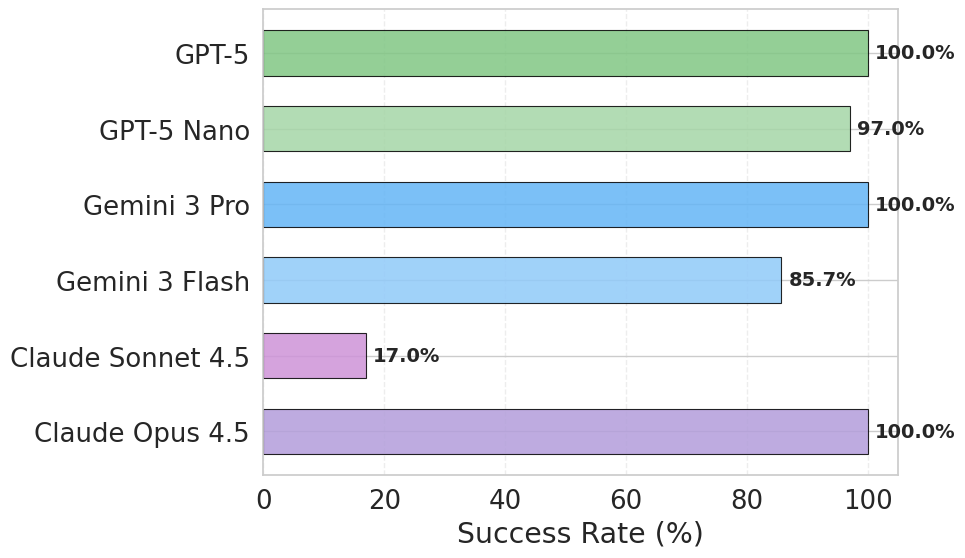


✓ Chart saved to: llm_success_rate.png


In [15]:
# Create horizontal bar chart for success rates
if len(success_stats) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    y = np.arange(len(success_stats))
    colors_success = [MODEL_COLORS[m] for m in success_stats.index]
    
    bars = ax.barh(y, success_stats["success_rate"], height=0.6,
                   color=colors_success, edgecolor="black", linewidth=0.8, alpha=0.85)
    
    ax.set_xlabel("Success Rate (%)")
    ax.set_yticks(y)
    ax.set_yticklabels(success_stats.index)
    ax.set_xlim(0, 105)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    
    # Add value labels
    for bar, rate in zip(bars, success_stats["success_rate"]):
        ax.annotate(f"{rate:.1f}%",
                    xy=(rate, bar.get_y() + bar.get_height()/2),
                    xytext=(5, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=14, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("llm_success_rate.png", dpi=300, bbox_inches="tight")
    plt.savefig("llm_success_rate.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("\n✓ Chart saved to: llm_success_rate.png")
else:
    print("Skipping success rate chart - no data available.")

## Plot 6: Cost Comparison by Model

Compare API costs per intent across different LLM providers.

**Cost calculation:** Based on official pricing (January 2026) for input and output tokens. Each intent requires two API calls (`intent_processing` + `type_definition`), and costs are aggregated per intent.

In [16]:
# Calculate cost statistics per model (per-intent aggregated)
cost_stats = intent_data.groupby("model_name").agg({
    "cost_total": ["sum", "mean", "std"],
    "cost_input": "sum",
    "cost_output": "sum",
    "intent": "count"
}).round(6)
cost_stats.columns = ["total_cost", "mean_cost", "std_cost", "input_cost", "output_cost", "samples"]

# Convert to cents for readability
cost_stats["cost_per_intent_cents"] = (cost_stats["mean_cost"] * 100).round(4)
cost_stats = cost_stats.reindex([m for m in model_order if m in cost_stats.index])

print("Cost Statistics (per intent - both rows summed):")
print("-" * 80)
for model in cost_stats.index:
    row = cost_stats.loc[model]
    print(f"{model:20s}: ${row['total_cost']:.4f} total | "
          f"{row['cost_per_intent_cents']:.4f}¢/intent | "
          f"(${row['input_cost']:.4f} input + ${row['output_cost']:.4f} output)")

Cost Statistics (per intent - both rows summed):
--------------------------------------------------------------------------------
Claude Opus 4.5     : $29.3251 total | 29.3251¢/intent | ($27.8215 input + $1.5036 output)
Claude Sonnet 4.5   : $4.8115 total | 4.8115¢/intent | ($4.5809 input + $0.2306 output)
Gemini 3 Flash      : $0.1430 total | 0.1857¢/intent | ($0.0871 input + $0.0558 output)
Gemini 3 Pro        : $2.4181 total | 3.1001¢/intent | ($1.4845 input + $0.9336 output)
GPT-5 Nano          : $0.4860 total | 0.4860¢/intent | ($0.3952 input + $0.0907 output)
GPT-5               : $7.6011 total | 7.6011¢/intent | ($6.8264 input + $0.7747 output)


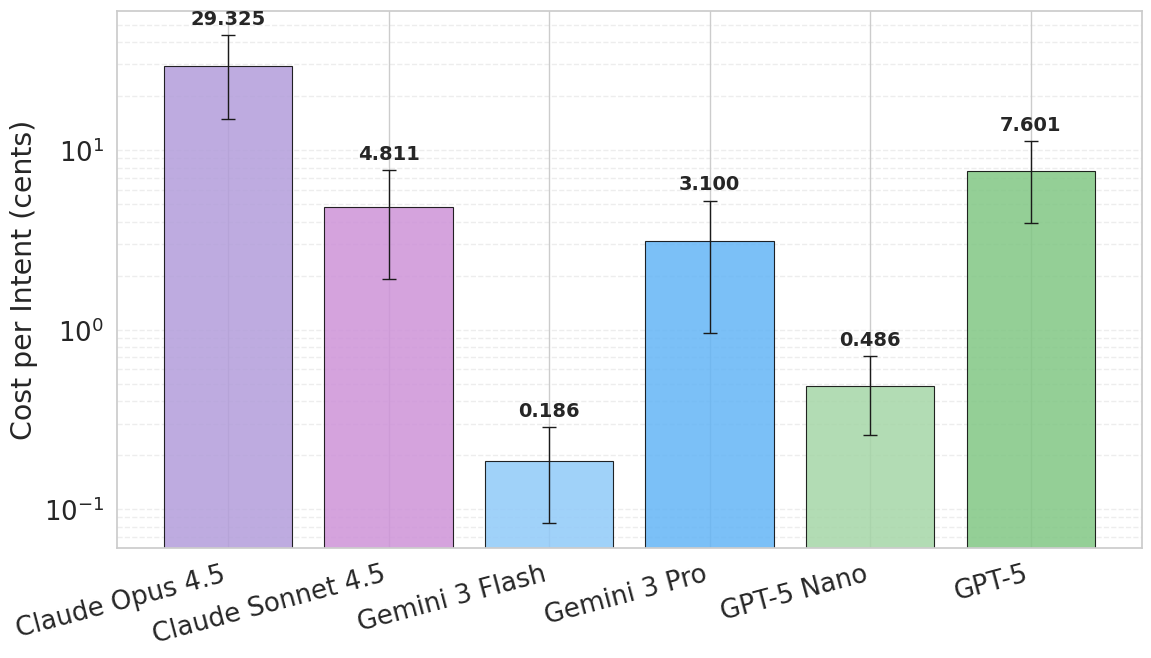


✓ Chart saved to: llm_cost_comparison.png


In [17]:
# Create bar chart for cost per intent
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(cost_stats))
colors = [MODEL_COLORS[m] for m in cost_stats.index]

bars = ax.bar(x, cost_stats["cost_per_intent_cents"], color=colors, 
              edgecolor="black", linewidth=0.8, alpha=0.85,
              yerr=cost_stats["std_cost"] * 100, capsize=5,
              error_kw=dict(lw=1, capsize=5, capthick=1))

ax.set_ylabel("Cost per Intent (cents)")
ax.set_xticks(x)
ax.set_xticklabels(cost_stats.index, rotation=15, ha="right")
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")

# Add value labels (positioned above stddev error bars)
for bar, val, std in zip(bars, cost_stats["cost_per_intent_cents"], cost_stats["std_cost"] * 100):
    ax.annotate(f"{val:.3f}",
                xy=(bar.get_x() + bar.get_width()/2, val + std),
                xytext=(0, 5), textcoords="offset points",
                ha="center", va="bottom", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("llm_cost_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_cost_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_cost_comparison.png")

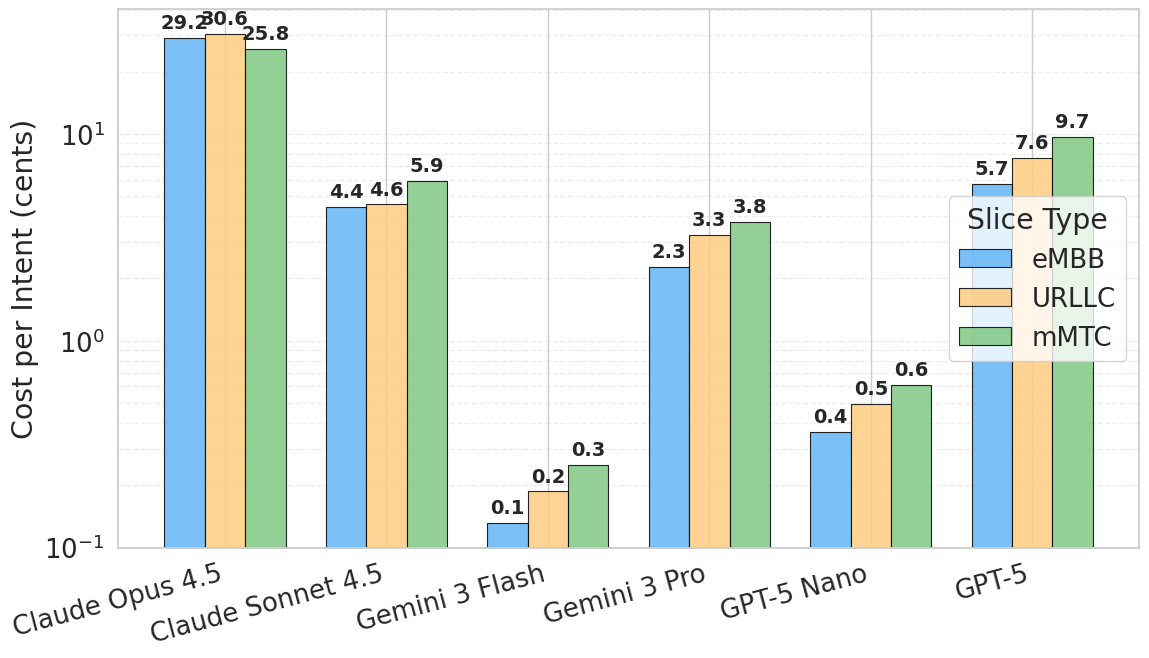


✓ Chart saved to: llm_cost_by_slice_type.png


In [18]:
# Create cost breakdown by slice type (per-intent aggregated)
fig, ax = plt.subplots(figsize=(12, 7))

slice_types = ["eMBB", "URLLC", "mMTC"]
slice_colors = {"eMBB": "#64B5F6", "URLLC": "#FFCC80", "mMTC": "#81C784"}

# Calculate cost by model and slice type
cost_by_slice = intent_data.groupby(["model_name", "slice_type"])["cost_total"].mean().unstack(fill_value=0) * 100
cost_by_slice = cost_by_slice.reindex(model_order).dropna(how="all")

x = np.arange(len(cost_by_slice))
width = 0.25

for i, slice_type in enumerate(slice_types):
    if slice_type in cost_by_slice.columns:
        values = cost_by_slice[slice_type].values
        bars = ax.bar(x + i*width, values, width, 
                      label=slice_type, color=slice_colors[slice_type],
                      edgecolor="black", linewidth=0.8, alpha=0.85)
        
        # Add value labels
        for bar, val in zip(bars, values):
            if val > 0:
                ax.annotate(f"{val:.1f}",
                            xy=(bar.get_x() + bar.get_width()/2, val),
                            xytext=(0, 4), textcoords="offset points",
                            ha="center", va="bottom", fontsize=14, fontweight="bold")

ax.set_ylabel("Cost per Intent (cents)")
ax.set_xticks(x + width)
ax.set_xticklabels(cost_by_slice.index, rotation=15, ha="right")
ax.legend(title="Slice Type", loc="center right")
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")

plt.tight_layout()
plt.savefig("llm_cost_by_slice_type.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_cost_by_slice_type.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_cost_by_slice_type.png")

## Plot 7: Context Growth Analysis

Line chart showing cumulative input tokens across conversation turns (row-level data).

**Purpose:** Visualize how input token consumption increases as conversation history accumulates. This helps identify models with efficient context management and predict costs for longer conversations.

In [19]:
# Analyze context growth (input tokens grow as conversation progresses)
# Using row-level data to show actual context accumulation

context_data = []
for model_name, df in dataframes.items():
    # Sort by index (assuming chronological order)
    df_sorted = df.sort_index().reset_index(drop=True)
    
    # Calculate rolling mean of input tokens (window of 10)
    df_sorted["turn"] = range(1, len(df_sorted) + 1)
    df_sorted["input_tokens_rolling"] = df_sorted["input_tokens"].rolling(window=10, min_periods=1).mean()
    
    context_data.append(df_sorted[["model_name", "turn", "input_tokens", "input_tokens_rolling"]])

context_df = pd.concat(context_data, ignore_index=True)

print("Context Growth Summary (row-level):")
print(context_df.groupby("model_name")["input_tokens"].agg(["min", "max", "mean"]).round(0).to_string())

Context Growth Summary (row-level):
                   min    max     mean
model_name                            
Claude Opus 4.5    283  38212   9274.0
Claude Sonnet 4.5  288  34591  13051.0
GPT-5              255  52783  13653.0
GPT-5 Nano         255  51421  13375.0
Gemini 3 Flash     255  29162   8126.0
Gemini 3 Pro       254  29162   7613.0


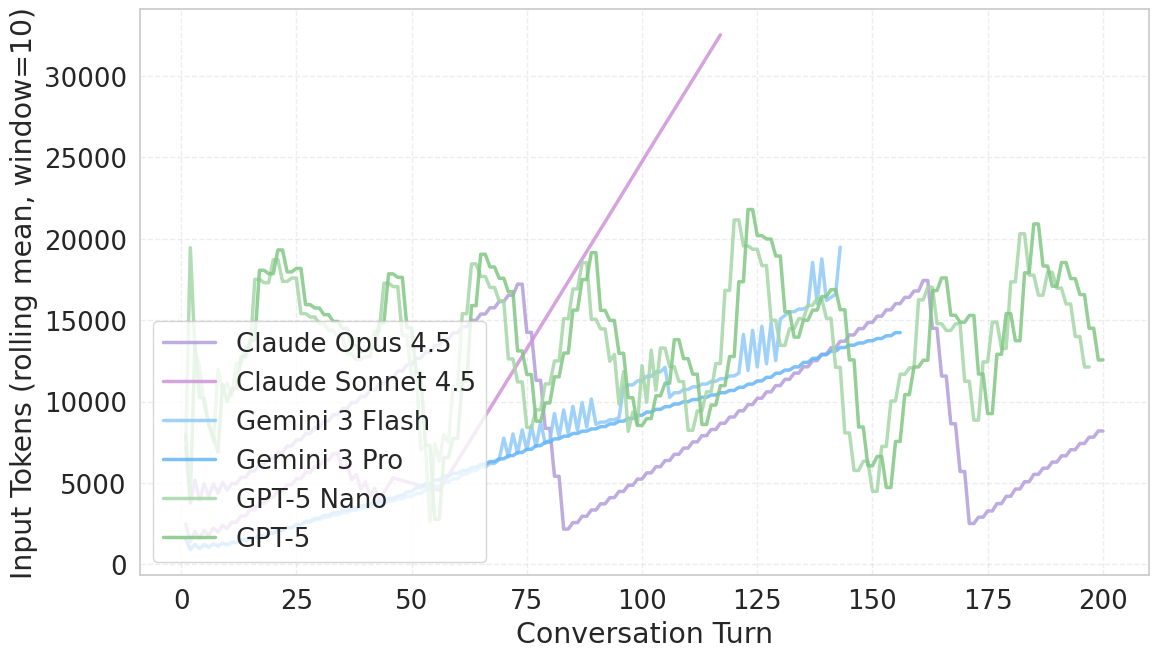


✓ Chart saved to: llm_context_growth.png


In [20]:
# Create line chart for context growth
fig, ax = plt.subplots(figsize=(12, 7))

for model_name in model_order:
    if model_name in context_df["model_name"].unique():
        model_data = context_df[context_df["model_name"] == model_name]
        ax.plot(model_data["turn"], model_data["input_tokens_rolling"], 
                label=model_name, color=MODEL_COLORS[model_name], 
                linewidth=2.5, alpha=0.85)

ax.set_xlabel("Conversation Turn")
ax.set_ylabel("Input Tokens (rolling mean, window=10)")
ax.legend(loc="lower left")
ax.grid(linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("llm_context_growth.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_context_growth.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_context_growth.png")

## Summary Statistics Table

Consolidated view of all metrics per model: token usage, latency, success rate, and cost per intent.

In [21]:
# Create comprehensive summary table (per-intent metrics)
print("=" * 100)
print("LLM PERFORMANCE SUMMARY (Per Intent)")
print("=" * 100)

summary_table = intent_data.groupby("model_name").agg({
    "intent": "count",
    "input_tokens": ["mean", "std"],
    "output_tokens": ["mean", "std"],
    "reasoning_tokens": "mean",
}).round(1)

summary_table.columns = ["Intents", "Input (mean)", "Input (std)", 
                         "Output (mean)", "Output (std)", "Reasoning (mean)"]


# Add success rate
summary_table["Success (%)"] = success_stats["success_rate"]

# Add cost per intent (in cents for readability)
cost_per_intent = intent_data.groupby("model_name")["cost_total"].mean() * 100  # cents
summary_table["Cost (¢/intent)"] = cost_per_intent.round(4)

# Reorder
summary_table = summary_table.reindex([m for m in model_order if m in summary_table.index])

print(summary_table.to_string())
print("=" * 100)

print("\nNote: Each intent consumes 2 CSV rows (intent_processing + type_definition).")
print("Success requires both rows present with 'Policy created successfully' status.")

LLM PERFORMANCE SUMMARY (Per Intent)
                   Intents  Input (mean)  Input (std)  Output (mean)  Output (std)  Reasoning (mean)  Success (%)  Cost (¢/intent)
model_name                                                                                                                        
Claude Opus 4.5        100       18547.6       9417.0          200.5         112.6               0.0        100.0          29.3251
Claude Sonnet 4.5      100       15269.8       9679.0          153.7          15.5               0.0         17.0           4.8115
Gemini 3 Flash          77       15090.3       8308.3         2417.7        2028.0            5271.7         85.7           0.1857
Gemini 3 Pro            78       15225.6       8172.6         2393.9        2786.7            4677.7        100.0           3.1001
GPT-5 Nano             100       26348.8      14797.3         1512.4         380.5            1420.8         97.0           0.4860
GPT-5                  100       27305.6      